In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [4]:
x, y = make_classification(n_samples=5000, n_features=15, n_classes=2, random_state=42)

col_names = [f"feature_{i}" for i in range(1, 16)]
print(x.shape, y.shape)

(5000, 15) (5000,)


In [5]:
df = pd.DataFrame(x, columns=col_names)
df["target"] = y

df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,target
0,0.280547,0.513707,0.600077,0.132933,-0.446743,-0.024305,1.925692,-1.975469,1.465833,0.266588,2.244387,-1.704060,-0.530315,-1.162787,0.862646,1
1,0.504257,0.491558,-0.180046,-0.169979,-0.595169,0.224075,-0.612825,-1.086411,-0.209787,-0.315192,-0.706853,-1.858125,0.694097,0.714817,-0.291406,0
2,-0.146550,0.550992,-0.342294,-0.078793,-0.023507,1.978164,-1.415985,0.931033,1.248097,-0.404016,-0.700930,-0.556282,-0.065374,-0.026593,1.255934,0
3,-0.941686,1.515026,0.252214,-0.882632,-0.732410,-1.784526,1.096197,0.145569,-1.266551,1.754573,0.173466,-0.121218,2.750949,-1.439122,-0.754718,1
4,0.160889,-0.417992,-0.425010,0.991153,0.157452,2.544566,-1.772444,-0.534075,1.643475,-1.200643,-1.727058,-1.147564,0.994472,1.124417,-0.448450,0


In [6]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,target
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.004138,0.007005,-0.004532,0.003887,0.022325,-0.003486,-0.013952,0.004411,-0.014965,0.009810,0.008520,-0.029790,0.004383,-0.008007,0.002150,0.501400
std,1.017070,1.012700,0.391300,1.005272,0.989346,1.287186,1.372241,0.984037,1.199636,0.990072,1.010052,1.002439,1.009519,0.999844,0.999780,0.500048
min,-4.295391,-3.419906,-1.612523,-4.157734,-3.335902,-4.948272,-5.108021,-3.421380,-4.483545,-4.465604,-3.856375,-3.448043,-3.334893,-3.635200,-3.655087,0.000000
25%,-0.664974,-0.687355,-0.277015,-0.669996,-0.652633,-0.529650,-1.044239,-0.673941,-1.017254,-0.645214,-0.689193,-0.708190,-0.688733,-0.687107,-0.682445,0.000000
50%,-0.004197,0.007575,-0.002034,0.011435,0.027539,0.007469,0.011325,0.026048,0.068860,0.019512,0.002979,-0.035853,0.000947,0.002753,0.010260,1.000000
75%,0.685718,0.703302,0.294896,0.692961,0.710235,0.439925,1.043776,0.669207,1.004802,0.682051,0.724974,0.648104,0.688797,0.659531,0.661239,1.000000
max,3.745379,3.727833,1.211331,3.691625,3.285724,4.507710,4.666389,3.451858,2.891048,4.479084,3.354573,3.611350,3.942331,3.471549,3.441520,1.000000


In [7]:
x = df.drop(columns=["target"], axis=1)
y = df["target"]

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.20, random_state=42)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = rf_model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       499
           1       0.92      0.90      0.91       501

    accuracy                           0.91      1000
   macro avg       0.91      0.91      0.91      1000
weighted avg       0.91      0.91      0.91      1000



In [15]:
importance_df = pd.DataFrame({
    "feature": x.columns,
    "importance": rf_model.feature_importances_
})


importance_df = importance_df.sort_values(by="importance", ascending=False)
importance_df

,feature,importance
6,feature_7,0.325742
2,feature_3,0.217477
5,feature_6,0.143310
8,feature_9,0.110509
13,feature_14,0.020227
1,feature_2,0.019591
10,feature_11,0.018931
11,feature_12,0.018592
3,feature_4,0.018359
0,feature_1,0.018261


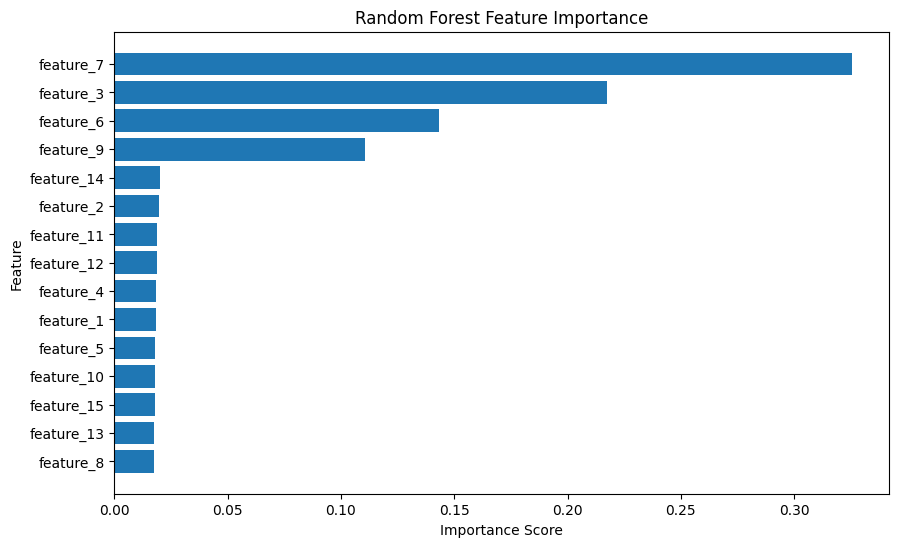

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()